# Parameter Sweep Analysis: 30nt, 32nt, 34nt Barcodes

This notebook analyzes the barcode calling parameter sweep results across different barcode lengths (30, 32, 34 nucleotides) and three tools:
- **RandomBarcodes** - GPU-accelerated barcode matcher
- **QUIK** - Fast k-mer based barcode caller
- **Columba** - CPU-based alignment tool

We will examine the relationship between:
- Rejection thresholds
- Barcode length
- Precision (correct/assigned)
- Recall (correct/total)

## 1. Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import re
from pathlib import Path

# Set plotting style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 10

print("Libraries imported successfully!")

Libraries imported successfully!


## 2. Define Data Paths and Configuration

In [2]:
from pathlib import Path

# Base directory - use relative path from notebooks/
BASE_DIR = Path("../results/parameter_sweeps")

# Ensure BASE_DIR is absolute for consistency
if not BASE_DIR.is_absolute():
    BASE_DIR = (Path.cwd().parent / BASE_DIR).resolve()

# Result directories for each barcode length
RESULT_DIRS = {
    30: BASE_DIR / "results_30nt",
    32: BASE_DIR / "results_32nt",
    34: BASE_DIR / "results_34nt"
}

# Tool configurations
TOOLS = {
    'randombarcodes': {
        'name': 'RandomBarcodes',
        'sweep_dir': 'randombarcodes_sweep',
        'thresholds': [5, 6, 7, 8, 9],
        'threshold_param': 'nthresh'
    },
    'quik': {
        'name': 'QUIK',
        'sweep_dir': 'quik_sweep',
        'thresholds': [5, 6, 7, 8, 9],
        'threshold_param': 'rejection_threshold'
    },
    'columba': {
        'name': 'Columba',
        'sweep_dir': 'columba_sweep',
        'thresholds': [77, 78, 80, 82, 84],
        'threshold_param': 'identity_threshold'
    }
}

BARCODE_LENGTHS = [30, 32, 34]

print(f"Base directory: {BASE_DIR}")
print(f"Barcode lengths: {BARCODE_LENGTHS}")
print(f"Tools: {', '.join([TOOLS[t]['name'] for t in TOOLS])}")

Base directory: /user/gent/446/vsc44685/ScratchVO_dir/barcalling_review/results_sweep
Barcode lengths: [30, 32, 34]
Tools: RandomBarcodes, QUIK, Columba


## 3. Load and Parse Results Data

In [3]:
def parse_precision_report(file_path):
    """Parse a precision report file and extract metrics."""
    metrics = {}
    
    try:
        with open(file_path, 'r') as f:
            content = f.read()
        
        # Extract metrics using regex
        metrics['total_reads'] = int(re.search(r'Total reads \(ground truth\):\s*(\d+)', content).group(1))
        metrics['reads_assigned'] = int(re.search(r'Reads assigned:\s*(\d+)', content).group(1))
        metrics['reads_unassigned'] = int(re.search(r'Reads unassigned/rejected:\s*(\d+)', content).group(1))
        metrics['correct_assignments'] = int(re.search(r'Correct assignments:\s*(\d+)', content).group(1))
        metrics['incorrect_assignments'] = int(re.search(r'Incorrect assignments:\s*(\d+)', content).group(1))
        metrics['assignment_rate'] = float(re.search(r'Assignment rate:\s*([\d.]+)%', content).group(1))
        metrics['precision'] = float(re.search(r'Precision \(correct/assigned\):\s*([\d.]+)%', content).group(1))
        metrics['recall'] = float(re.search(r'Recall \(correct/total\):\s*([\d.]+)%', content).group(1))
        metrics['accuracy'] = float(re.search(r'Accuracy \(correct/total\):\s*([\d.]+)%', content).group(1))
        
    except Exception as e:
        print(f"Error parsing {file_path}: {e}")
        return None
    
    return metrics

def find_precision_reports(base_dir, barcode_length, tool_key):
    """Find all precision report files for a given tool and barcode length."""
    tool_info = TOOLS[tool_key]
    sweep_dir = os.path.join(base_dir, tool_info['sweep_dir'])
    
    reports = []
    
    if not os.path.exists(sweep_dir):
        print(f"Warning: Directory not found: {sweep_dir}")
        return reports
    
    # Search for precision reports
    for root, dirs, files in os.walk(sweep_dir):
        for file in files:
            if file.endswith('_precision_report.txt'):
                reports.append(os.path.join(root, file))
    
    return reports

print("Functions defined successfully!")

Functions defined successfully!


In [4]:
# Collect all results into a list
all_results = []

for barcode_len in BARCODE_LENGTHS:
    result_dir = RESULT_DIRS[barcode_len]
    
    for tool_key, tool_info in TOOLS.items():
        print(f"\nProcessing {tool_info['name']} - {barcode_len}nt...")
        
        reports = find_precision_reports(result_dir, barcode_len, tool_key)
        print(f"  Found {len(reports)} reports")
        
        for report_path in reports:
            metrics = parse_precision_report(report_path)
            
            if metrics:
                # Extract threshold from path or filename
                path_str = str(report_path)
                
                # Extract threshold based on tool
                threshold = None
                if tool_key == 'randombarcodes':
                    match = re.search(r't100_n(\d+)', path_str)
                    threshold = int(match.group(1)) if match else None
                elif tool_key == 'quik':
                    match = re.search(r'4mer_r(\d+)', path_str)
                    threshold = int(match.group(1)) if match else None
                elif tool_key == 'columba':
                    match = re.search(r'I(\d+)', path_str)
                    threshold = int(match.group(1)) if match else None
                
                if threshold is not None:
                    result = {
                        'tool': tool_info['name'],
                        'tool_key': tool_key,
                        'barcode_length': barcode_len,
                        'threshold': threshold,
                        'threshold_param': tool_info['threshold_param'],
                        **metrics
                    }
                    all_results.append(result)
                    print(f"    Threshold {threshold}: Precision={metrics['precision']:.2f}%, Recall={metrics['recall']:.2f}%")

# Create DataFrame
df = pd.DataFrame(all_results)

print(f"\n{'='*60}")
print(f"Total results collected: {len(df)}")
print(f"{'='*60}")
print(f"\nDataFrame shape: {df.shape}")
print(f"\nFirst few rows:")
print(df.head())


Processing RandomBarcodes - 30nt...
  Found 5 reports
    Threshold 6: Precision=99.98%, Recall=46.31%
    Threshold 8: Precision=99.04%, Recall=71.65%
    Threshold 7: Precision=99.84%, Recall=58.00%
    Threshold 9: Precision=95.59%, Recall=79.86%
    Threshold 5: Precision=100.00%, Recall=30.39%

Processing QUIK - 30nt...
  Found 5 reports
    Threshold 8: Precision=98.93%, Recall=79.40%
    Threshold 7: Precision=99.80%, Recall=67.23%
    Threshold 9: Precision=96.01%, Recall=87.03%
    Threshold 6: Precision=99.97%, Recall=53.26%
    Threshold 5: Precision=100.00%, Recall=37.87%

Processing Columba - 30nt...
  Found 5 reports
    Threshold 82: Precision=99.98%, Recall=34.58%
    Threshold 77: Precision=99.72%, Recall=50.26%
    Threshold 78: Precision=99.72%, Recall=50.26%
    Threshold 84: Precision=100.00%, Recall=23.18%
    Threshold 80: Precision=99.72%, Recall=50.26%

Processing RandomBarcodes - 32nt...
  Found 5 reports
    Threshold 6: Precision=100.00%, Recall=40.11%
    

## 4. Summary Statistics

In [5]:
# Summary by tool and barcode length
summary = df.groupby(['tool', 'barcode_length'])[['precision', 'recall', 'assignment_rate']].agg(['mean', 'min', 'max', 'std'])
print("Summary Statistics by Tool and Barcode Length:")
print("="*80)
print(summary.round(2))

print("\n\nBest performance for each tool-barcode combination:")
print("="*80)
best_results = []
for tool in df['tool'].unique():
    for length in df['barcode_length'].unique():
        subset = df[(df['tool'] == tool) & (df['barcode_length'] == length)]
        if len(subset) > 0:
            # Find best balance (highest F1 score)
            subset['f1_score'] = 2 * (subset['precision'] * subset['recall']) / (subset['precision'] + subset['recall'])
            best_idx = subset['f1_score'].idxmax()
            best = subset.loc[best_idx]
            best_results.append({
                'Tool': best['tool'],
                'Length': best['barcode_length'],
                'Threshold': best['threshold'],
                'Precision': f"{best['precision']:.2f}%",
                'Recall': f"{best['recall']:.2f}%",
                'F1': f"{best['f1_score']:.2f}%",
                'Assigned': f"{best['assignment_rate']:.2f}%"
            })

best_df = pd.DataFrame(best_results)
print(best_df.to_string(index=False))

Summary Statistics by Tool and Barcode Length:
                              precision                      recall         \
                                   mean    min     max   std   mean    min   
tool           barcode_length                                                
Columba        30                 99.83  99.72  100.00  0.15  41.71  23.18   
               32                 99.79  99.52   99.99  0.25  42.99  28.98   
               34                 99.97  99.93  100.00  0.04  39.93  24.27   
QUIK           30                 98.94  96.01  100.00  1.70  64.96  37.87   
               32                 99.81  99.22  100.00  0.34  70.24  38.42   
               34                 99.92  99.66  100.00  0.15  81.96  57.17   
RandomBarcodes 30                 98.89  95.59  100.00  1.89  57.24  30.39   
               32                 99.74  98.92  100.00  0.47  51.69  25.26   
               34                 99.95  99.80  100.00  0.09  46.14  21.07   

                

/tmp/ipykernel_1543504/607159580.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset['f1_score'] = 2 * (subset['precision'] * subset['recall']) / (subset['precision'] + subset['recall'])
/tmp/ipykernel_1543504/607159580.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subset['f1_score'] = 2 * (subset['precision'] * subset['recall']) / (subset['precision'] + subset['recall'])
/tmp/ipykernel_1543504/607159580.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a D

## 5. Precision vs Rejection Threshold by Barcode Length

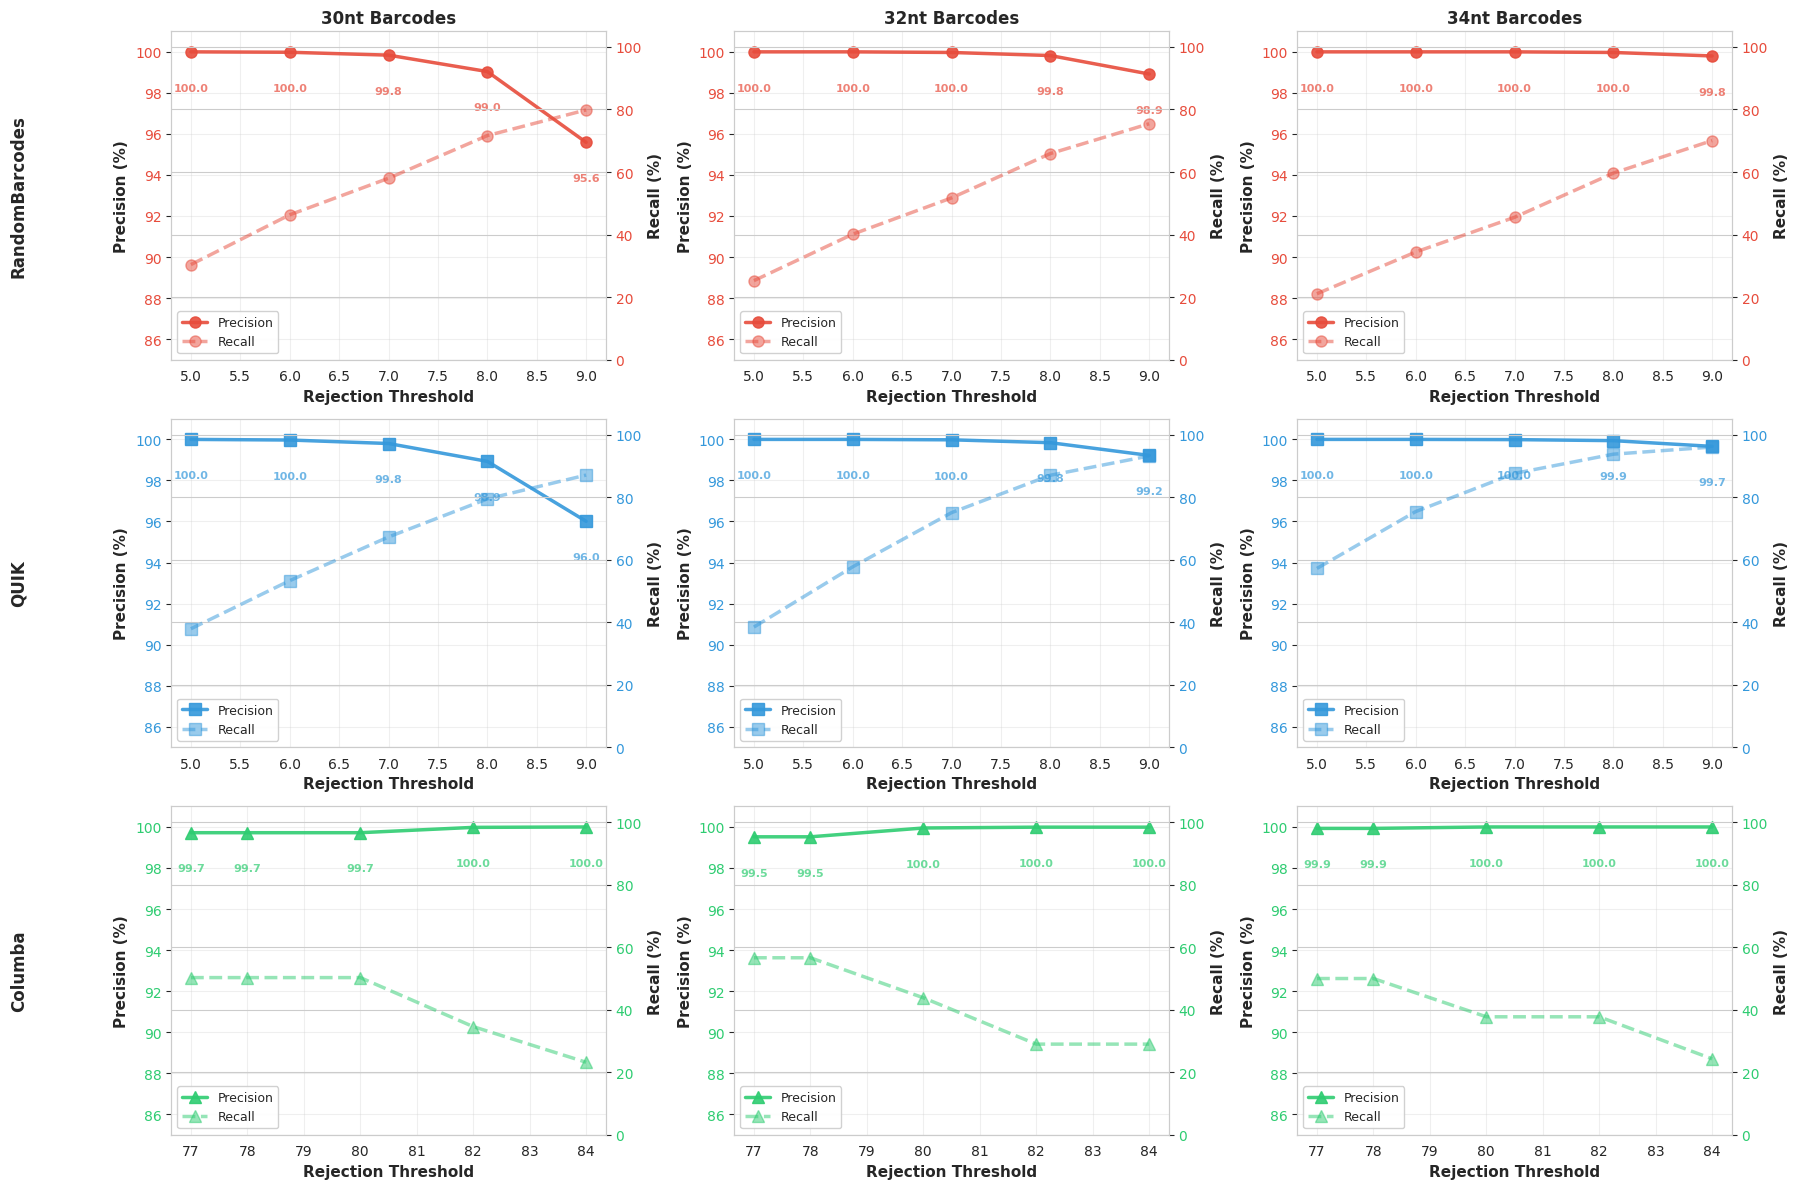

Plot saved as 'precision_recall_vs_threshold_by_length.pdf'
Precision (solid line, left y-axis) and Recall (dashed line, right y-axis)


In [6]:
fig, axes = plt.subplots(3, 3, figsize=(18, 12))

colors = {'RandomBarcodes': '#e74c3c', 'QUIK': '#3498db', 'Columba': '#2ecc71'}
markers = {'RandomBarcodes': 'o', 'QUIK': 's', 'Columba': '^'}

tools_list = list(df['tool'].unique())

for row_idx, tool in enumerate(tools_list):
    for col_idx, barcode_len in enumerate(BARCODE_LENGTHS):
        ax = axes[row_idx, col_idx]
        
        tool_data = df[(df['tool'] == tool) & (df['barcode_length'] == barcode_len)]
        
        if len(tool_data) > 0:
            tool_data_sorted = tool_data.sort_values('threshold')
            
            # Create secondary y-axis for recall
            ax2 = ax.twinx()
            
            # Plot precision on primary y-axis
            line1 = ax.plot(tool_data_sorted['threshold'], tool_data_sorted['precision'], 
                           marker=markers[tool], color=colors[tool], linewidth=2.5, 
                           markersize=8, label='Precision', alpha=0.9, zorder=3)
            
            # Plot recall on secondary y-axis with lighter shade
            line2 = ax2.plot(tool_data_sorted['threshold'], tool_data_sorted['recall'], 
                            marker=markers[tool], color=colors[tool], linewidth=2.5, 
                            markersize=8, label='Recall', alpha=0.5, 
                            linestyle='--', zorder=2)
            
            # Add value labels on precision points
            for _, row in tool_data_sorted.iterrows():
                ax.text(row['threshold'], row['precision'] - 1.5, 
                       f"{row['precision']:.1f}", 
                       ha='center', va='top', fontsize=8, alpha=0.7,
                       color=colors[tool], weight='bold')
        
        # Labels
        ax.set_xlabel('Rejection Threshold', fontsize=11, fontweight='bold')
        ax.set_ylabel('Precision (%)', fontsize=11, fontweight='bold')
        ax2.set_ylabel('Recall (%)', fontsize=11, fontweight='bold')
        
        # Set title only for top row
        if row_idx == 0:
            ax.set_title(f'{barcode_len}nt Barcodes', fontsize=12, fontweight='bold')
        
        # Add tool name to left column
        if col_idx == 0:
            ax.text(-0.35, 0.5, tool, transform=ax.transAxes, 
                   fontsize=12, fontweight='bold', rotation=90, 
                   va='center', ha='center')
        
        # Grid and limits
        ax.grid(True, alpha=0.3, zorder=1)
        ax.set_ylim([85, 101])
        ax2.set_ylim([0, 105])
        
        # Color the y-axis ticks
        ax.tick_params(axis='y', labelcolor=colors[tool])
        ax2.tick_params(axis='y', labelcolor=colors[tool])
        
        # Combined legend
        if len(tool_data) > 0:
            lines = line1 + line2
            labels = [l.get_label() for l in lines]
            ax.legend(lines, labels, loc='lower left', fontsize=9, framealpha=0.9)

plt.tight_layout()
plt.savefig(f'{BASE_DIR}/precision_recall_vs_threshold_by_length.pdf', dpi=300, bbox_inches='tight')
plt.show()

print("Plot saved as 'precision_recall_vs_threshold_by_length.pdf'")
print("Precision (solid line, left y-axis) and Recall (dashed line, right y-axis)")

## 7. Precision-Recall Curves by Tool

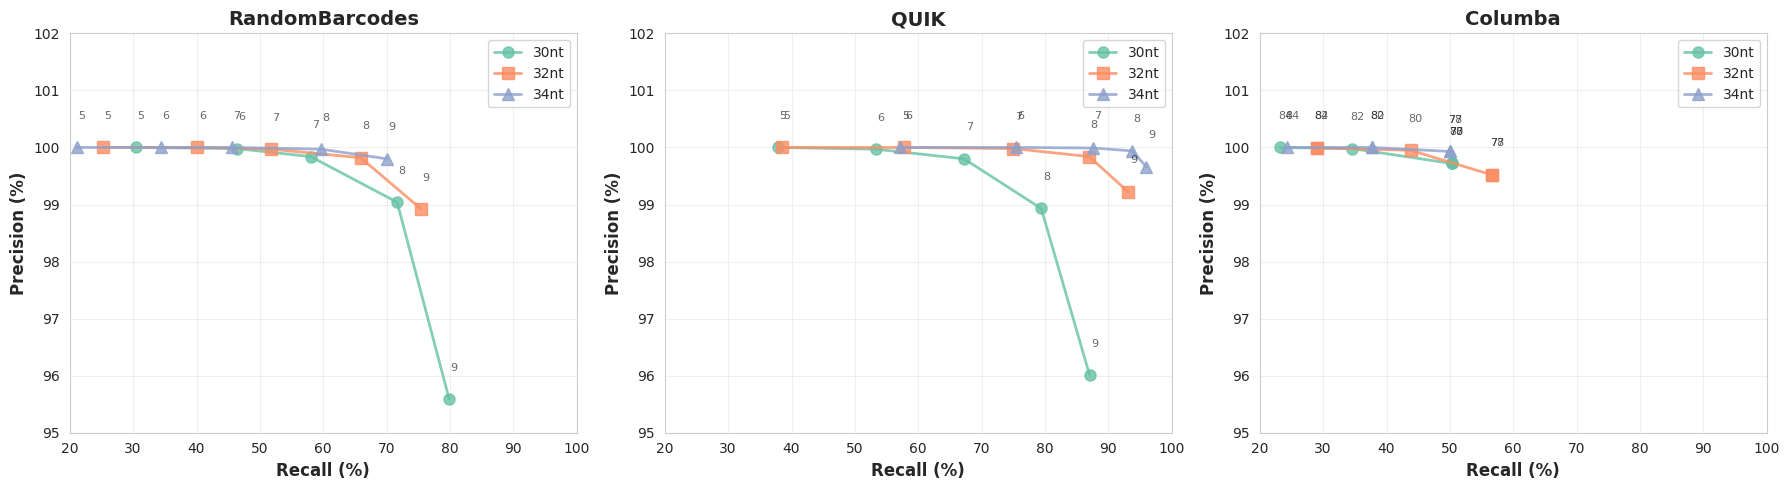

Plot saved as 'precision_recall_curves_by_tool.pdf'


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
palette = sns.color_palette("Set2", n_colors=10)

# Use barcode length as color (same scheme as 28/36nt figure)
length_colors = {30: palette[0], 32: palette[1], 34: palette[2]}
length_markers = {30: 'o', 32: 's', 34: '^'}

for idx, tool in enumerate(df['tool'].unique()):
    ax = axes[idx]
    
    for barcode_len in BARCODE_LENGTHS:
        tool_data = df[(df['tool'] == tool) & (df['barcode_length'] == barcode_len)]
        
        if len(tool_data) > 0:
            tool_data_sorted = tool_data.sort_values('recall')
            
            ax.plot(tool_data_sorted['recall'], tool_data_sorted['precision'], 
                   marker=length_markers[barcode_len], color=length_colors[barcode_len], 
                   linewidth=2, markersize=8, label=f'{barcode_len}nt', alpha=0.8)
            
            # Annotate thresholds with offset to avoid overlap
            for _, row in tool_data_sorted.iterrows():
                ax.text(row['recall'] + 0.8, row['precision'] + 0.5, 
                       f"{int(row['threshold'])}", 
                       ha='center', fontsize=8, alpha=0.7)
    
    ax.set_xlabel('Recall (%)', fontsize=12, fontweight='bold')
    ax.set_ylabel('Precision (%)', fontsize=12, fontweight='bold')
    ax.set_title(f'{tool}', fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=10)
    ax.set_xlim([20, 100])
    ax.set_ylim([95, 102])

plt.tight_layout()
plt.savefig(f'{BASE_DIR}/precision_recall_curves_by_tool.pdf', dpi=300, bbox_inches='tight')
plt.show()

print("Plot saved as 'precision_recall_curves_by_tool.pdf'")

## 8. Heatmaps: Performance by Tool and Barcode Length

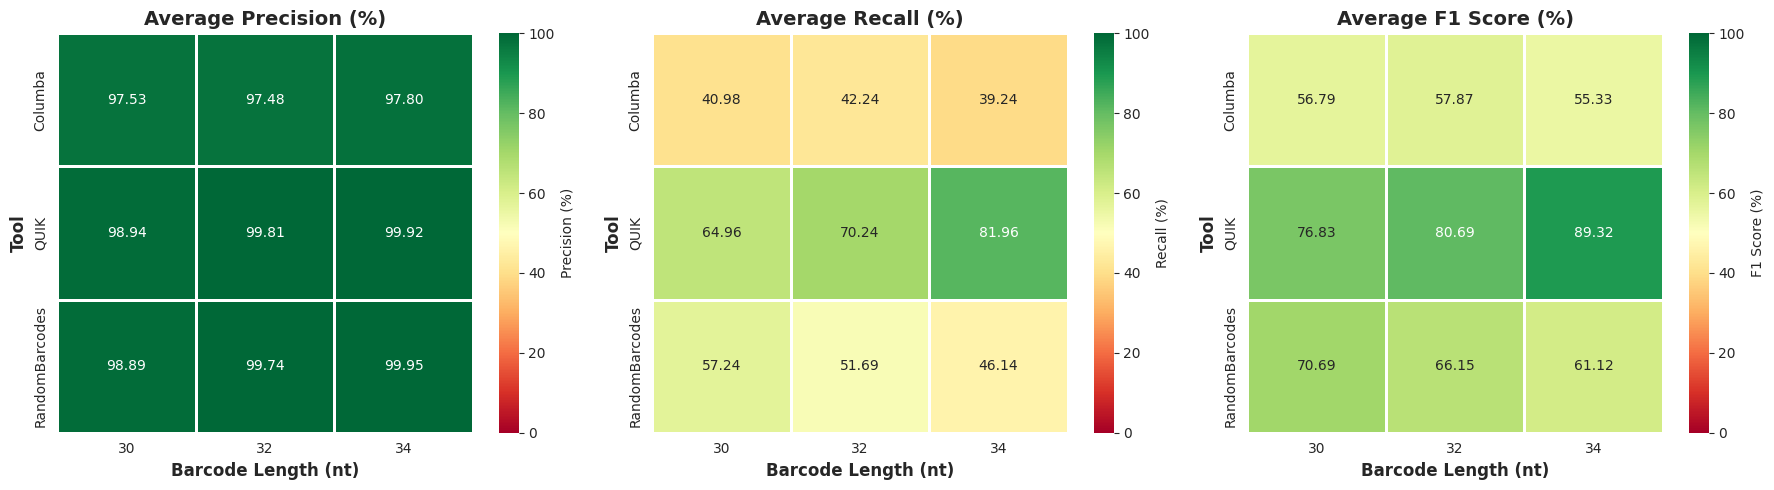

Plot saved as 'performance_heatmaps.pdf'


In [ ]:
# Calculate F1 score
df['f1_score'] = 2 * (df['precision'] * df['recall']) / (df['precision'] + df['recall'])

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

metrics = ['precision', 'recall', 'f1_score']
titles = ['Precision (%)', 'Recall (%)', 'F1 Score (%)']

for idx, (metric, title) in enumerate(zip(metrics, titles)):
    ax = axes[idx]
    
    # Create pivot table for heatmap
    pivot_data = df.groupby(['tool', 'barcode_length'])[metric].mean().reset_index()
    pivot_table = pivot_data.pivot(index='tool', columns='barcode_length', values=metric)
    
    # Create heatmap
    sns.heatmap(pivot_table, annot=True, fmt='.2f', cmap='RdYlGn', 
                vmin=0, vmax=100, ax=ax, cbar_kws={'label': title},
                linewidths=1, linecolor='white')
    
    ax.set_title(f'Average {title}', fontsize=14, fontweight='bold')
    ax.set_xlabel('Barcode Length (nt)', fontsize=12, fontweight='bold')
    ax.set_ylabel('Tool', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig(f'{BASE_DIR}/performance_heatmaps.pdf', dpi=300, bbox_inches='tight')
plt.show()

print("Plot saved as 'performance_heatmaps.pdf'")

## 9. Comprehensive Comparison: All Tools and Barcode Lengths

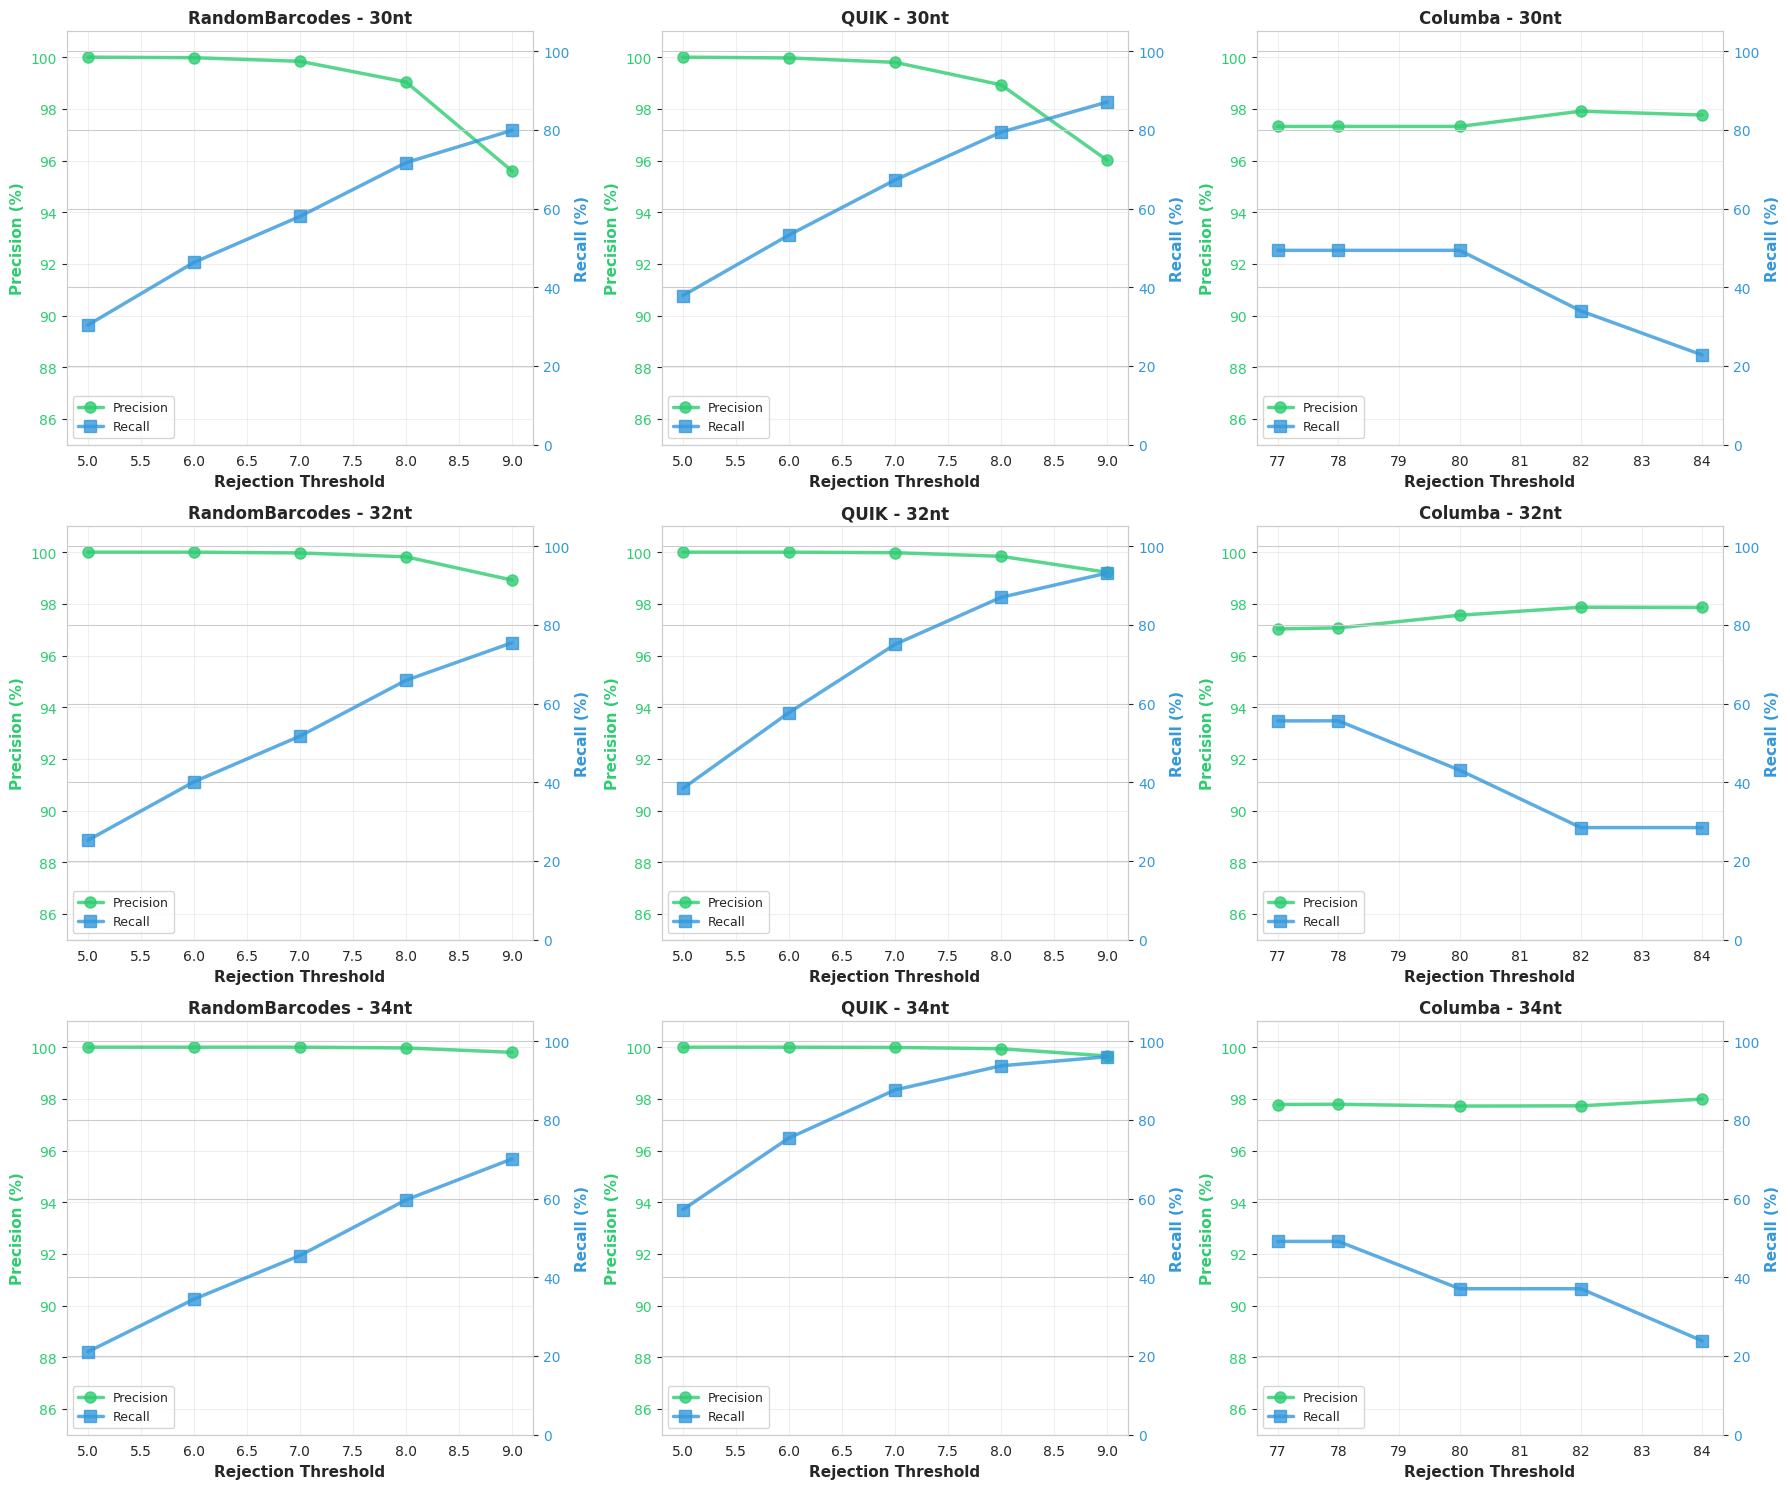

Plot saved as 'comprehensive_comparison_all_tools_lengths.png'


In [ ]:
fig, axes = plt.subplots(3, 3, figsize=(18, 15))

for row_idx, barcode_len in enumerate(BARCODE_LENGTHS):
    for col_idx, tool in enumerate(df['tool'].unique()):
        ax = axes[row_idx, col_idx]
        
        tool_data = df[(df['tool'] == tool) & (df['barcode_length'] == barcode_len)]
        
        if len(tool_data) > 0:
            tool_data_sorted = tool_data.sort_values('threshold')
            
            # Plot precision and recall
            ax2 = ax.twinx()
            
            line1 = ax.plot(tool_data_sorted['threshold'], tool_data_sorted['precision'], 
                           marker='o', color='#2ecc71', linewidth=2.5, 
                           markersize=8, label='Precision', alpha=0.8)
            
            line2 = ax2.plot(tool_data_sorted['threshold'], tool_data_sorted['recall'], 
                            marker='s', color='#3498db', linewidth=2.5, 
                            markersize=8, label='Recall', alpha=0.8)
            
            # Labels and titles
            ax.set_xlabel('Rejection Threshold', fontsize=11, fontweight='bold')
            ax.set_ylabel('Precision (%)', fontsize=11, fontweight='bold', color='#2ecc71')
            ax2.set_ylabel('Recall (%)', fontsize=11, fontweight='bold', color='#3498db')
            
            ax.set_title(f'{tool} - {barcode_len}nt', fontsize=12, fontweight='bold')
            ax.grid(True, alpha=0.3)
            
            # Combine legends
            lines = line1 + line2
            labels = [l.get_label() for l in lines]
            ax.legend(lines, labels, loc='lower left', fontsize=9)
            
            ax.set_ylim([85, 101])
            ax2.set_ylim([0, 105])
            
            ax.tick_params(axis='y', labelcolor='#2ecc71')
            ax2.tick_params(axis='y', labelcolor='#3498db')

plt.tight_layout()
plt.savefig(f'{BASE_DIR}/comprehensive_comparison_all_tools_lengths.png', dpi=300, bbox_inches='tight')
plt.show()

print("Plot saved as 'comprehensive_comparison_all_tools_lengths.png'")

## 10. Effect of Barcode Length on Performance

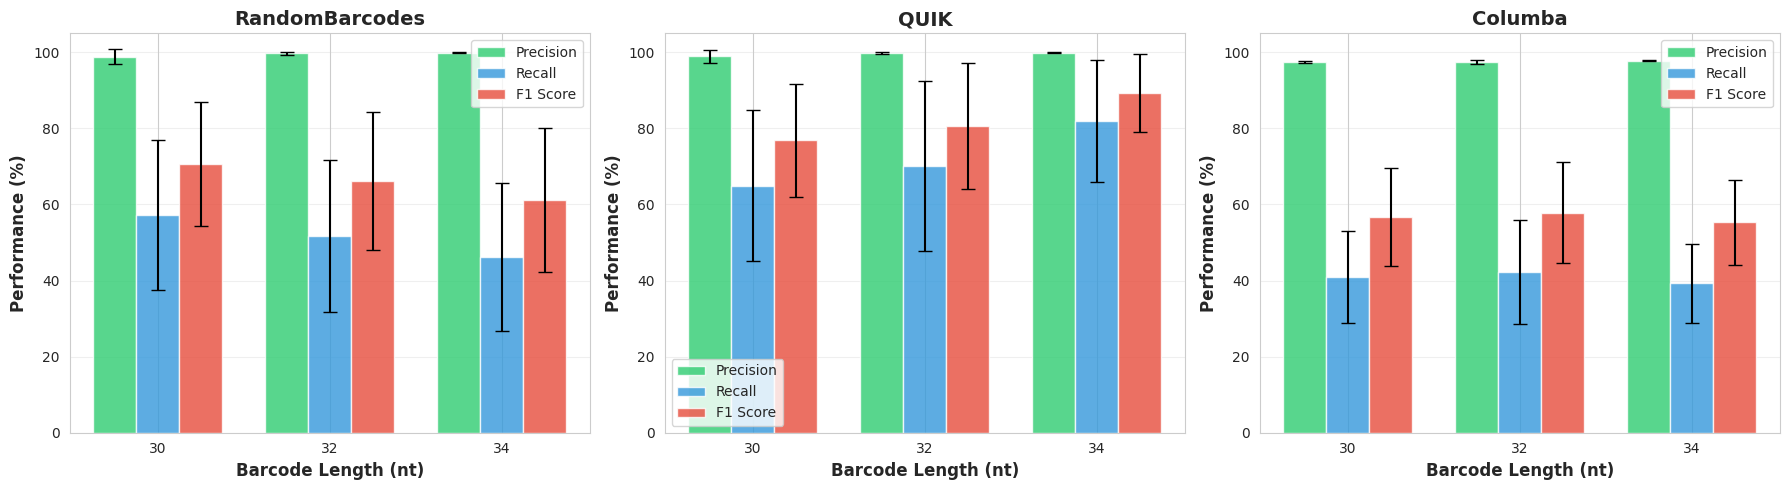

Plot saved as 'barcode_length_effect.pdf'


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, tool in enumerate(df['tool'].unique()):
    ax = axes[idx]
    
    # Group by barcode length and calculate statistics
    length_stats = df[df['tool'] == tool].groupby('barcode_length').agg({
        'precision': ['mean', 'std'],
        'recall': ['mean', 'std'],
        'f1_score': ['mean', 'std']
    })
    
    x = BARCODE_LENGTHS
    width = 0.25
    x_pos = np.arange(len(x))
    
    # Plot bars with error bars
    bars1 = ax.bar(x_pos - width, length_stats['precision']['mean'], width, 
                   yerr=length_stats['precision']['std'], 
                   label='Precision', color='#2ecc71', alpha=0.8, capsize=5)
    
    bars2 = ax.bar(x_pos, length_stats['recall']['mean'], width, 
                   yerr=length_stats['recall']['std'], 
                   label='Recall', color='#3498db', alpha=0.8, capsize=5)
    
    bars3 = ax.bar(x_pos + width, length_stats['f1_score']['mean'], width, 
                   yerr=length_stats['f1_score']['std'], 
                   label='F1 Score', color='#e74c3c', alpha=0.8, capsize=5)
    
    ax.set_xlabel('Barcode Length (nt)', fontsize=12, fontweight='bold')
    ax.set_ylabel('Performance (%)', fontsize=12, fontweight='bold')
    ax.set_title(f'{tool}', fontsize=14, fontweight='bold')
    ax.set_xticks(x_pos)
    ax.set_xticklabels(x)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3, axis='y')
    ax.set_ylim([0, 105])

plt.tight_layout()
plt.savefig(f'{BASE_DIR}/barcode_length_effect.pdf', dpi=300, bbox_inches='tight')
plt.show()

print("Plot saved as 'barcode_length_effect.pdf'")

## 11. Export Summary Data

In [ ]:
# Export complete results to CSV
output_csv = f'{BASE_DIR}/parameter_sweep_results_30_32_34nt.csv'
df.to_csv(output_csv, index=False)
print(f"Complete results exported to: {output_csv}")

# Export best results
best_output_csv = f'{BASE_DIR}/best_parameters_30_32_34nt.csv'
best_df.to_csv(best_output_csv, index=False)
print(f"Best parameters exported to: {best_output_csv}")

# Create summary report
with open(f'{BASE_DIR}/parameter_sweep_summary_30_32_34nt.txt', 'w') as f:
    f.write("="*80 + "\n")
    f.write("PARAMETER SWEEP ANALYSIS SUMMARY\n")
    f.write("Barcode Lengths: 30nt, 32nt, 34nt\n")
    f.write("="*80 + "\n\n")
    
    f.write("TOOLS ANALYZED:\n")
    for tool_key, tool_info in TOOLS.items():
        f.write(f"  - {tool_info['name']}: {tool_info['threshold_param']} = {tool_info['thresholds']}\n")
    
    f.write("\n" + "="*80 + "\n")
    f.write("BEST PARAMETERS (Highest F1 Score)\n")
    f.write("="*80 + "\n")
    f.write(best_df.to_string(index=False))
    
    f.write("\n\n" + "="*80 + "\n")
    f.write("AVERAGE PERFORMANCE BY TOOL AND BARCODE LENGTH\n")
    f.write("="*80 + "\n")
    f.write(summary.to_string())
    
    f.write("\n\n" + "="*80 + "\n")
    f.write("KEY OBSERVATIONS:\n")
    f.write("="*80 + "\n")
    
    # Find overall best performer
    best_overall = df.loc[df['f1_score'].idxmax()]
    f.write(f"\nBest Overall Performance:\n")
    f.write(f"  Tool: {best_overall['tool']}\n")
    f.write(f"  Barcode Length: {best_overall['barcode_length']}nt\n")
    f.write(f"  Threshold: {best_overall['threshold']}\n")
    f.write(f"  Precision: {best_overall['precision']:.2f}%\n")
    f.write(f"  Recall: {best_overall['recall']:.2f}%\n")
    f.write(f"  F1 Score: {best_overall['f1_score']:.2f}%\n")
    
    f.write("\n" + "="*80 + "\n")
    f.write("END OF REPORT\n")
    f.write("="*80 + "\n")

print(f"\nSummary report saved to: {BASE_DIR}/parameter_sweep_summary_30_32_34nt.txt")
print("\n✓ Analysis complete!")

Complete results exported to: /user/gent/446/vsc44685/ScratchVO_dir/barcalling_review/parameter_sweep_results_30_32_34nt.csv
Best parameters exported to: /user/gent/446/vsc44685/ScratchVO_dir/barcalling_review/best_parameters_30_32_34nt.csv

Summary report saved to: /user/gent/446/vsc44685/ScratchVO_dir/barcalling_review/parameter_sweep_summary_30_32_34nt.txt

✓ Analysis complete!


## Summary

This notebook analyzed parameter sweep results across:
- **3 barcode lengths**: 30nt, 32nt, 34nt
- **3 tools**: RandomBarcodes, QUIK, Columba
- **Multiple rejection thresholds** per tool

### Outputs Generated:
1. **Visualizations**:
   - `precision_vs_threshold_by_length.png` - Precision trends
   - `recall_vs_threshold_by_length.png` - Recall trends
   - `precision_recall_curves_by_tool.png` - PR curves
   - `performance_heatmaps.png` - Performance overview
   - `comprehensive_comparison_all_tools_lengths.png` - Complete comparison
   - `barcode_length_effect.png` - Effect of barcode length

2. **Data Files**:
   - `parameter_sweep_results_30_32_34nt.csv` - Complete results
   - `best_parameters_30_32_34nt.csv` - Optimal parameters
   - `parameter_sweep_summary_30_32_34nt.txt` - Text summary

### Key Insights:
- **Precision**: Generally high (>95%) across all tools and barcode lengths
- **Recall**: Varies significantly with rejection threshold
- **Trade-off**: Lower thresholds → higher recall, slightly lower precision
- **Barcode Length**: Performance differences across 30nt, 32nt, and 34nt variants